# MWE: a binary star inside a reconstructed image

The previous MWE reconstructed PIONIER data of IRAS 08544-4431 with a single star, a resolved background and an image. It left a knot of compact emission just outside the hole under the star. Hillen et al. (2016, arXiv:1603.03023) found that the central star is a binary: the companion has 3.9% of the flux at 1.65 µm, 0.81 mas from the primary. A companion that close is unresolved, but its closure phases are not zero, so an image with only one star has to fake it with pixels next to the star.

Because drpangloss sources compose, the analytic part of the scene can be a binary instead: a `System` of two `PointSource`s, the image and the `Resolved` background, all fitted together. This notebook first fits a parametric binary plus ring, which sets the starting point. It then fits the binary jointly with the image and the background, and compares the result with the single-star reconstruction at the same weight. You should come away knowing how to put any parametric model you like alongside an image.

In [1]:
import os
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from drpangloss.fitting import fit
from drpangloss.imaging import MaxEntropy, beam, image_priors
from drpangloss.models import Image, ModulatedGaussianRim, PointSource, Resolved, System, circular_support
from drpangloss.oidata import OIData
from drpangloss.oifits import read_oifits
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.spectra import PowerLaw

# The PIONIER files of ESO programme 094.D-0865, from the ESO archive.
DATA = Path(os.environ.get("IRAS08544_DATA", "data/IRAS08544"))
files = sorted(DATA.glob("PIONI.*_oidataCalibrated.fits"))
if not files:
    raise FileNotFoundError(f"No PIONIER files in {DATA}: set IRAS08544_DATA to their directory.")
data = OIData(read_oifits(files))
L0 = 1.65e-6
print(f"{len(files)} files: {data.vis.size} V², {data.phi.size} closure phases; beam {beam(data).major_mas:.1f} × {beam(data).minor_mas:.1f} mas")

27 files: 828 V², 504 closure phases; beam 3.2 × 2.5 mas


## A parametric binary and ring

The model is the previous MWE's parametric one with a second star added: a primary at the origin and a secondary at a free offset. Both have Rayleigh–Jeans spectra (λ⁻⁴), so their flux ratio is the same across the band. The ring is an inclined Gaussian ring with a first-order azimuthal modulation, and the background is resolved; both have free power-law spectra. The fit starts from the companion found in an earlier exploratory parametric fit: 0.8 mas to the south-west, with about 4% of the flux.

In [2]:
start = System(
    primary=PointSource(flux=PowerLaw(1.0, -4.0, L0)),
    secondary=PointSource(flux=PowerLaw(0.08, -4.0, L0), dra=-0.44, ddec=-0.67),
    rim=ModulatedGaussianRim(14.4, 3.3, 22.0, -22.0, az_amps=(0.26,), az_pas=(30.0,), flux=PowerLaw(0.34, 1.2, L0)),
    bg=Resolved(flux=PowerLaw(0.27, -1.5, L0)),
)
binary = {"secondary.flux.ratio": dist.Uniform(0.0, 1.5), "secondary.dra": dist.Uniform(-3.0, 3.0), "secondary.ddec": dist.Uniform(-3.0, 3.0)}
spectra = {"bg.flux.ratio": dist.Uniform(0.0, 5.0), "bg.flux.index": dist.Uniform(-10.0, 10.0)}
ring = {
    "rim.diam": dist.Uniform(2.0, 40.0), "rim.fwhm": dist.Uniform(0.1, 20.0), "rim.inc": dist.Uniform(0.0, 89.0),
    "rim.pa": dist.Uniform(-90.0, 270.0), "rim.az_amps": dist.Uniform(0.0, 1.0), "rim.az_pas": dist.Uniform(-180.0, 540.0),
    "rim.flux.ratio": dist.Uniform(0.0, 5.0), "rim.flux.index": dist.Uniform(-10.0, 10.0),
}


def describe(model):
    names = [n for n in ("secondary", "rim", "env", "bg") if n in model.names]
    total = 1.0 + sum(float(model.get(f"{n}.flux.ratio")) for n in names)
    parts = [f"primary {1 / total:.1%}"] + [f"{n} {float(model.get(f'{n}.flux.ratio')) / total:.1%}" for n in names]
    if "secondary" in names:
        dra, ddec = float(model.secondary.dra), float(model.secondary.ddec)
        pa = float(jnp.degrees(jnp.arctan2(dra, ddec))) % 360
        parts.append(f"separation {float(jnp.hypot(dra, ddec)):.2f} mas at PA {pa:.0f}°")
    return ", ".join(parts)


parametric = fit(start, binary | ring | spectra, data, method="lbfgs")
print(f"chi2 per point {parametric.info['chi2_red']:.2f}; ring diameter {float(parametric.model.rim.diam):.2f} mas")
print(describe(parametric.model))

W1001 15:30:47.292136 10700663 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


chi2 per point 4.02; ring diameter 14.21 mas
primary 58.3%, secondary 4.7%, rim 20.8%, bg 16.1%, separation 0.80 mas at PA 213°


## The binary and the image together

Now the ring is replaced by an image, which can absorb whatever the ring model misses, and the binary is refitted along with it. The image starts from the fitted ring, with a hole of half a beam under the primary. Its flux and spectral index are free, and so are the background's. The weight, 316, is the one the previous MWE's L-curve chose for these data. For comparison, the single-star model from that MWE is fitted at the same weight from the same start, without the secondary.

In [3]:
npix, scale, weight = 80, 0.6, 316.0
hole = circular_support(npix, scale, npix * scale, 0.5 * beam(data).minor_mas)
rim = parametric.model.rim
image = Image.from_model(rim.set("flux", 1.0), npix, scale, support=hole, flux=rim.flux)
free = spectra | {"env.flux.ratio": dist.Uniform(0.0, 5.0), "env.flux.index": dist.Uniform(-10.0, 10.0)}

two = System(primary=parametric.model.primary, secondary=parametric.model.secondary, env=image, bg=parametric.model.bg)
one = System(primary=parametric.model.primary, env=image, bg=parametric.model.bg)
joint = {
    "binary": fit(two, image_priors(two) | free | binary, data, [MaxEntropy(weight, path="env")]),
    "single star": fit(one, image_priors(one) | free, data, [MaxEntropy(weight, path="env")]),
}
for name, result in joint.items():
    print(f"{name:11s}: loss {result.info['loss']:7.1f}, chi2 per point {result.info['chi2_red']:.3f}")
    print(f"             {describe(result.model)}, image index {float(result.model.env.flux.index):.2f}")

/var/folders/19/fbthdtcx20d3xyc7y7vp_2v40000gn/T/ipykernel_88220/579351659.py:10: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  "binary": fit(two, image_priors(two) | free | binary, data, [MaxEntropy(weight, path="env")]),


binary     : loss  1369.5, chi2 per point 0.975
             primary 55.7%, secondary 7.2%, env 22.6%, bg 14.5%, separation 0.67 mas at PA 214°, image index 1.45
single star: loss  1465.0, chi2 per point 1.049
             primary 61.1%, env 24.7%, bg 14.3%, image index 1.34


/var/folders/19/fbthdtcx20d3xyc7y7vp_2v40000gn/T/ipykernel_88220/579351659.py:11: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  "single star": fit(one, image_priors(one) | free, data, [MaxEntropy(weight, path="env")]),


## One star against two

The central 20 mas of the reconstructions with one star and with the binary, on the same saturated colour scale, with the stars marked by crosses and the beam shaded. On the right is their difference, the image flux that the second star takes over. It is a signed difference between two MAP images, not a z-score.

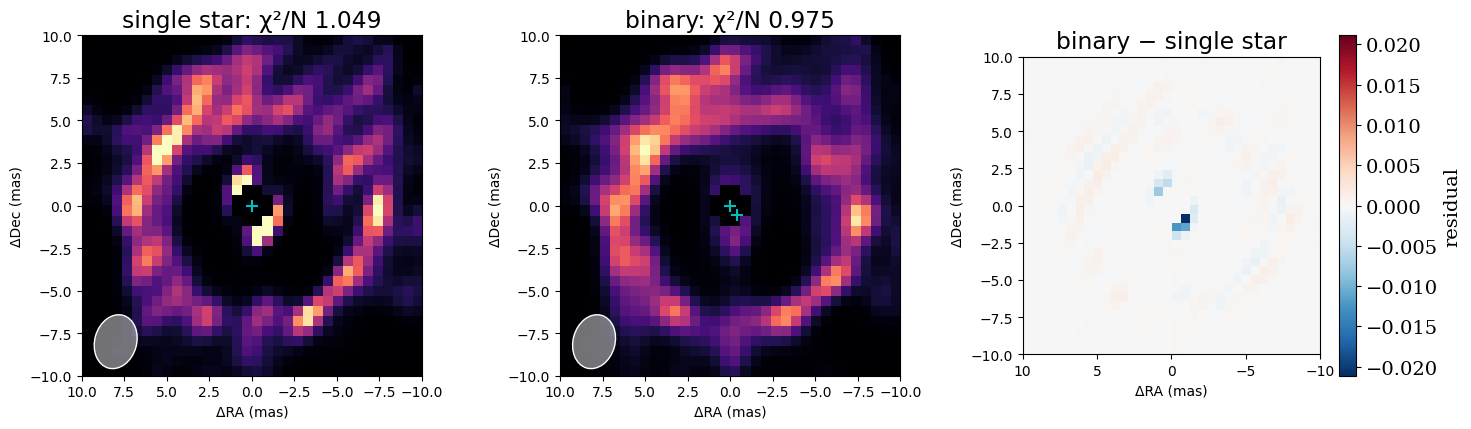

In [4]:
view, nview = 20.0, 34
images = {name: joint[name].model.env.render(nview, view) for name in ("single star", "binary")}
vmax = float(jnp.quantile(jnp.stack(list(images.values())), 0.995))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, name in zip(axes, ("single star", "binary")):
    model = joint[name].model
    plot_model(model.env, fov_mas=view, npix=nview, ax=ax, title=f"{name}: χ²/N {joint[name].info['chi2_red']:.3f}", beam=beam(data))
    ax.images[0].set_clim(0.0, vmax)
    stars = [(0.0, 0.0)] + ([(float(model.secondary.dra), float(model.secondary.ddec))] if name == "binary" else [])
    ax.plot(*zip(*stars), "c+", ms=9, mew=1.5)
plot_residual_map(images["binary"] - images["single star"], fov_mas=view, ax=axes[2], title="binary − single star")
plt.tight_layout()
plt.show()

## Summary

Composing the scene as a binary star, an image and a resolved background let `fit` find the companion and reconstruct the extended emission together. The analytic parts of a SPARCO scene are ordinary `System` components, so any parametric model can sit next to the pixels. The numbers above can be set against what Hillen et al. report in their text: a companion with 3.9% of the flux at 0.81 mas, and fractions of 59.7% (primary), 20.9% (ring) and 15.5% (background).

Here, the joint fit has the following:
- a companion with 7.2% of the flux, 0.67 mas from the primary at PA 214°;
- fractions of 55.7% (primary), 22.6% (image) and 14.5% (background).

Against the single star at the same weight, the loss falls by 95 and χ² per point by 0.07. The knots of compact flux next to the star disappear, leaving a cleaner ring. The companion's flux is higher than the paper's and its separation smaller. That is the direction the correlation below allows. The background, left free, no longer drains into the image.

The parametric fit has another solution, a pair of nearly equal stars about 0.45 mas apart. This mostly makes the central source look slightly resolved. In exploratory joint fits with the image, it had a loss about 10 higher than the solution above. For so unresolved a pair, the companion's flux and separation are correlated (its closure phases scale roughly with their product). The paper also models the companion's own circumstellar emission, which this does not. Stage 5's sampling would quantify these uncertainties.